In [1]:
import os, time, random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as T
from torchvision.datasets import CIFAR10, CIFAR100

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score


In [2]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


In [4]:
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2023, 0.1994, 0.2010)

CLASSES = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

train_transforms = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(CIFAR_MEAN, CIFAR_STD),
])

test_transforms = T.Compose([
    T.ToTensor(),
    T.Normalize(CIFAR_MEAN, CIFAR_STD),
])


In [5]:
train_dataset = CIFAR10(
    root="./data",
    train=True,
    transform=train_transforms,
    download=True
)

test_dataset = CIFAR10(
    root="./data",
    train=False,
    transform=test_transforms,
    download=True
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)


100%|██████████| 170M/170M [00:01<00:00, 98.3MB/s]


In [6]:
cifar100_dataset = CIFAR100(
    root="./data",
    train=False,
    transform=test_transforms,
    download=True
)

cifar100_loader = DataLoader(cifar100_dataset, batch_size=128, shuffle=False, num_workers=2)


100%|██████████| 169M/169M [00:01<00:00, 90.5MB/s]


In [7]:
class CifarCNN(nn.Module):
    def __init__(self, num_classes=10, dropout_prob=0.25):
        super().__init__()

        def conv_block(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),

                nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),

                nn.MaxPool2d(2),
                nn.Dropout(dropout_prob)
            )

        self.features = nn.Sequential(
            conv_block(3, 32),
            conv_block(32, 64),
            conv_block(64, 128)
        )

        self.tail = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1)
        )

        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.tail(x)
        x = torch.flatten(x, 1)
        logits = self.fc(x)
        return logits


In [8]:
model = CifarCNN().to(device)


In [9]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.SGD(
    model.parameters(),
    lr=0.05,
    momentum=0.9,
    nesterov=True,
    weight_decay=5e-4
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=80)
scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))


/tmp/ipython-input-2684910774.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))


In [10]:
def train_one_epoch(epoch_index):
    model.train()

    correct = 0
    total = 0
    running_loss = 0
    start_time = time.time()

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            logits = model(imgs)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        correct += (logits.argmax(1) == labels).sum().item()
        total += batch_size

    train_loss = running_loss / total
    train_acc = 100 * correct / total

    print(f"Train Epoch {epoch_index} | Loss {train_loss:.4f} | Acc {train_acc:.2f}% | Time {time.time()-start_time:.1f}s")

    return train_loss, train_acc


In [11]:
@torch.no_grad()
def evaluate(epoch_index):
    model.eval()

    correct = 0
    total = 0
    running_loss = 0

    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        logits = model(imgs)
        loss = criterion(logits, labels)

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        correct += (logits.argmax(1) == labels).sum().item()
        total += batch_size

    val_loss = running_loss / total
    val_acc = 100 * correct / total

    print(f"Valid Epoch {epoch_index} | Loss {val_loss:.4f} | Acc {val_acc:.2f}%")

    return val_loss, val_acc


In [12]:
EPOCHS = 50
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0

os.makedirs("checkpoints", exist_ok=True)

for epoch in range(1, EPOCHS + 1):

    tr_loss, tr_acc = train_one_epoch(epoch)
    val_loss, val_acc = evaluate(epoch)

    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc

        torch.save(
            {"model": model.state_dict(), "acc": best_val_acc, "epoch": epoch},
            "checkpoints/cifar10_cnn.pt"
        )

        print(f" Saved best model @ acc = {best_val_acc:.2f}%")


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/tmp/ipython-input-1364227050.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


Train Epoch 1 | Loss 1.5684 | Acc 50.69% | Time 405.5s
Valid Epoch 1 | Loss 1.3540 | Acc 62.11%
 Saved best model @ acc = 62.11%
Train Epoch 2 | Loss 1.2671 | Acc 65.91% | Time 406.0s
Valid Epoch 2 | Loss 1.1770 | Acc 71.31%
 Saved best model @ acc = 71.31%
Train Epoch 3 | Loss 1.1601 | Acc 71.36% | Time 408.6s
Valid Epoch 3 | Loss 1.1295 | Acc 73.93%
 Saved best model @ acc = 73.93%
Train Epoch 4 | Loss 1.0951 | Acc 74.31% | Time 406.0s
Valid Epoch 4 | Loss 1.0868 | Acc 76.06%
 Saved best model @ acc = 76.06%
Train Epoch 5 | Loss 1.0542 | Acc 76.48% | Time 406.4s
Valid Epoch 5 | Loss 1.0688 | Acc 76.02%
Train Epoch 6 | Loss 1.0267 | Acc 77.72% | Time 403.6s
Valid Epoch 6 | Loss 1.0237 | Acc 77.86%
 Saved best model @ acc = 77.86%
Train Epoch 7 | Loss 1.0032 | Acc 78.67% | Time 403.1s
Valid Epoch 7 | Loss 1.0498 | Acc 77.01%
Train Epoch 8 | Loss 0.9876 | Acc 79.28% | Time 402.3s
Valid Epoch 8 | Loss 0.9760 | Acc 80.71%
 Saved best model @ acc = 80.71%
Train Epoch 9 | Loss 0.9731 | Acc 

In [14]:
checkpoint = torch.load("checkpoints/cifar10_cnn.pt", map_location=device)
model.load_state_dict(checkpoint["model"])
model.eval()

print(" Loaded best model from epoch:", checkpoint["epoch"])


 Loaded best model from epoch: 48


In [15]:
def odin_score(loader, model, epsilon=0.0014, temperature=1000):
    model.eval()
    scores = []

    for imgs, _ in loader:
        imgs = imgs.to(device)
        imgs.requires_grad = True

        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            logits = model(imgs) / temperature
            max_idx = logits.argmax(1)
            loss = nn.CrossEntropyLoss()(logits, max_idx)

        grad = torch.autograd.grad(loss, imgs)[0]

        perturbed_imgs = imgs - epsilon * torch.sign(grad)

        with torch.no_grad():
            logits_perturbed = model(perturbed_imgs) / temperature
            probs = torch.softmax(logits_perturbed, dim=1)
            max_prob, _ = probs.max(dim=1)

            scores.extend(max_prob.cpu().numpy())

    return np.array(scores)


In [16]:
print("Computing ODIN scores...")

odin_id   = odin_score(test_loader, model)
odin_c100 = odin_score(cifar100_loader, model)


Computing ODIN scores...


/tmp/ipython-input-413860408.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


In [17]:
y_true = np.concatenate([
    np.ones_like(odin_id),
    np.zeros_like(odin_c100)
])

y_score = np.concatenate([odin_id, odin_c100])

auc = roc_auc_score(y_true, y_score)

print(f"\n ODIN AUROC (CIFAR-10 vs CIFAR-100) = {auc:.4f}")



 ODIN AUROC (CIFAR-10 vs CIFAR-100) = 0.8217


In [18]:
def show_ood_samples(loader, scores, topk=5, dataset_name="OOD"):
    imgs,_ = next(iter(loader))
    imgs = imgs[:len(scores)]
    scores = scores[:len(imgs)]

    top_idx = np.argsort(scores)[-topk:]
    low_idx = np.argsort(scores)[:topk]

    def plot_images(indices, title):
        plt.figure(figsize=(15,3))
        for i, idx in enumerate(indices):
            plt.subplot(1, len(indices), i+1)
            img = imgs[idx].permute(1,2,0).numpy()
            img = np.clip(img, 0, 1)
            plt.imshow(img)
            plt.title(f"{scores[idx]:.4f}")
            plt.axis('off')
        plt.suptitle(title)
        plt.show()

    plot_images(top_idx, f"{dataset_name} - Top {topk} ODIN scores")
    plot_images(low_idx, f"{dataset_name} - Lowest {topk} ODIN scores")


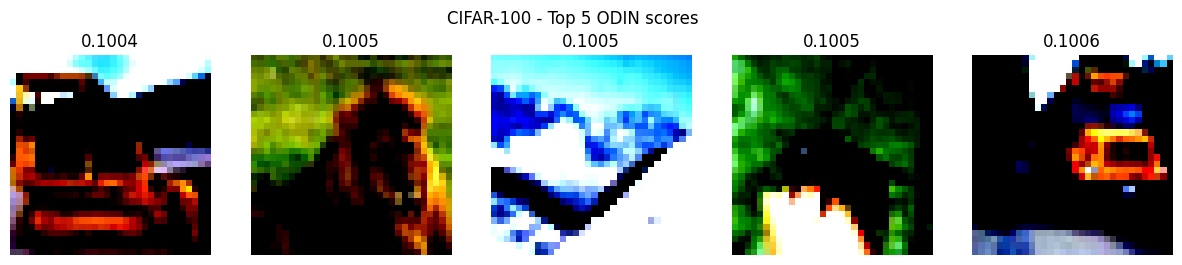

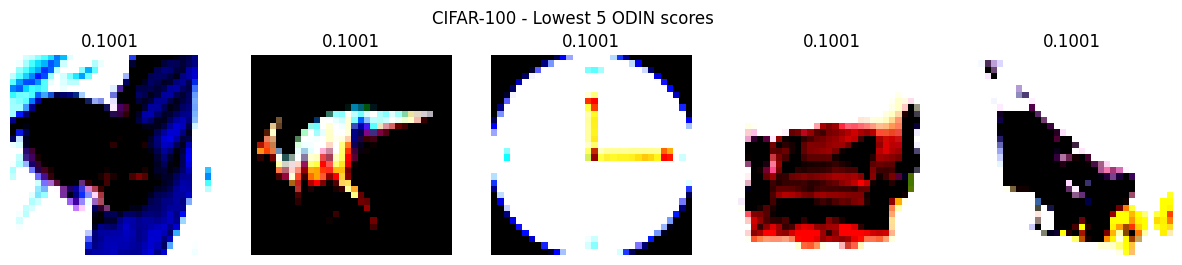

In [19]:
show_ood_samples(cifar100_loader, odin_c100, topk=5, dataset_name="CIFAR-100")


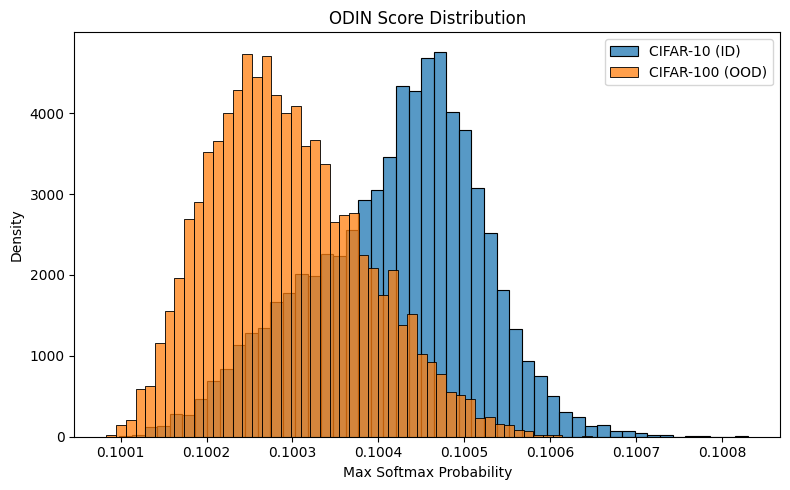

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(odin_id, label='CIFAR-10 (ID)', stat='density', bins=50)
sns.histplot(odin_c100, label='CIFAR-100 (OOD)', stat='density', bins=50)

plt.title("ODIN Score Distribution")
plt.xlabel("Max Softmax Probability")
plt.legend()
plt.tight_layout()
plt.savefig("odin_distribution.png", dpi=200)
plt.show()
